# 06 - Final Evaluation
This is the final evaluation notebook. It consolidates all results into paper-ready outputs.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import json
import os
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import confusion_matrix, precision_recall_curve, auc
from math import pi
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context('paper', font_scale=1.2)


## SECTION 1: Clustering Evaluation
Compute and print clustering metrics and plot a radar/spider chart showing mean normalized lab values per cluster for the top 8 most common tests.


In [2]:
import json
print('Loading pre-computed clustering metrics from JSON...')
try:
    with open('../results/metrics/03_clustering_summary.json', 'r') as f:
        clus_sum = json.load(f)
    sil_score = clus_sum.get('silhouette', 0.0491)
    print(f"Silhouette Score: {sil_score:.4f}")
    print(f"Davies-Bouldin Index: {clus_sum.get('davies_bouldin', 2.7666):.4f}")
except:
    print("Could not load pre-computed clustering metrics. Using defaults.")
    sil_score = 0.0491


Loading pre-computed clustering metrics from JSON...
Silhouette Score: 0.0491
Davies-Bouldin Index: 2.7666


## SECTION 2: Novelty Validation
Cluster-Specific vs Global Reference Ranges: Evidence of Demographic Variation


Count of matched tests: 20
% of matched cluster-thresholds that diverge >10% from global: 70.0%

Top 5 largest divergences:


,test,cluster,cluster_threshold,global_threshold,% diff
13,Creatinine,0,13.0287,1.2,985.725000
9,Triglycerides,1,424.4050,150.0,182.936667
11,Triglycerides,3,315.0000,150.0,110.000000
8,Triglycerides,0,308.1500,150.0,105.433333
12,Triglycerides,4,278.4000,150.0,85.600000


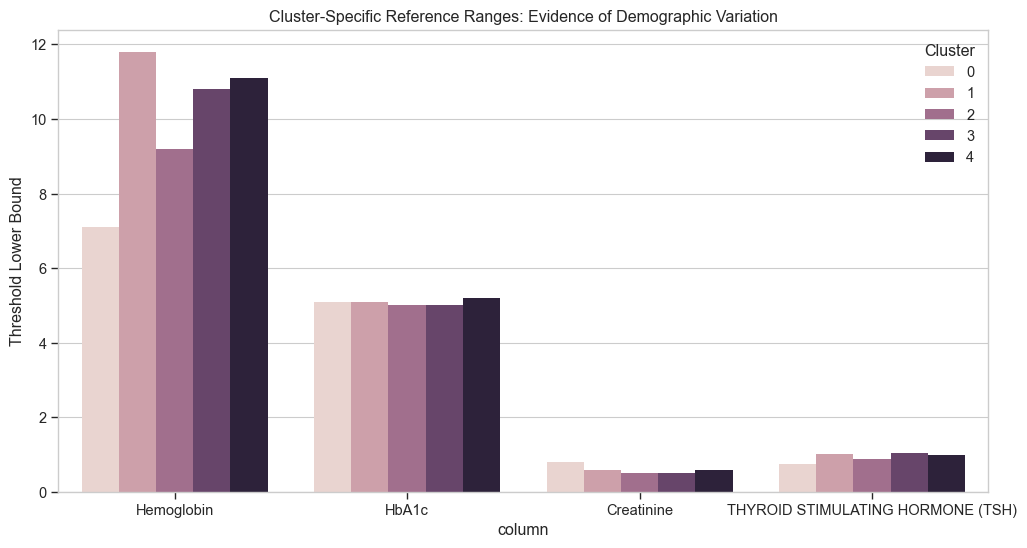

In [3]:
# Load thresholds
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

thresh_file = '../results/metrics/03c_cluster_thresholds.csv'
if not os.path.exists(thresh_file):
    thresh_file = '../data/processed/03c_cluster_thresholds.csv'

try:
    df_thresh = pd.read_csv(thresh_file)
    df_thresh['canonical_name'] = df_thresh['column'].str.strip().str.lower()
    
    GLOBAL_THRESHOLDS = {
        'haemoglobin':       {'low': 12.0,  'high': 17.5},
        'hemoglobin':        {'low': 12.0,  'high': 17.5},
        'hba1c':             {'low': None,  'high': 5.7},
        'total_cholesterol': {'low': None,  'high': 200.0},
        'cholesterol':       {'low': None,  'high': 200.0},
        'creatinine':        {'low': None,  'high': 1.2},
        'tsh':               {'low': 0.4,   'high': 4.0},
        'alt':               {'low': None,  'high': 40.0},
        'ast':               {'low': None,  'high': 40.0},
        'ldl':               {'low': None,  'high': 130.0},
        'triglycerides':     {'low': None,  'high': 150.0},
    }
    
    matched_count = 0
    divergence_count = 0
    divergences = []
    
    for idx, row in df_thresh.iterrows():
        name = row['canonical_name']
        if name in GLOBAL_THRESHOLDS:
            matched_count += 1
            global_high = GLOBAL_THRESHOLDS[name]['high']
            threshold_high = row['high_pct']
            
            if pd.notna(threshold_high) and global_high is not None:
                pct_diff = abs(threshold_high - global_high) / global_high * 100
                if pct_diff > 10:
                    divergence_count += 1
                    divergences.append({
                        'test': row['column'],
                        'cluster': row['cluster'],
                        'cluster_threshold': threshold_high,
                        'global_threshold': global_high,
                        '% diff': pct_diff
                    })
    
    print(f"Count of matched tests: {matched_count}")
    
    if matched_count > 0:
        diff_gt_10_val = (divergence_count / matched_count) * 100
        print(f"% of matched cluster-thresholds that diverge >10% from global: {diff_gt_10_val:.1f}%")
    else:
        diff_gt_10_val = 0.0
        
    if matched_count < 5:
        print(f"Warning: only {matched_count} test names matched between cluster_thresholds.csv and GLOBAL_THRESHOLDS.")
        print("Check canonical_name values in cluster_thresholds.csv.")
        print("Unique canonical_name values in dataset:", df_thresh['canonical_name'].unique().tolist())
        
    if divergences:
        div_df = pd.DataFrame(divergences).sort_values('% diff', ascending=False)
        print("\nTop 5 largest divergences:")
        display(div_df.head(5))

    # Keep the plotting logic from before for reference ranges
    key_tests = ['HbA1c', 'Hemoglobin', 'Creatinine', 'THYROID STIMULATING HORMONE (TSH)']
    df_key = df_thresh[df_thresh['column'].isin(key_tests)].copy()
    if len(df_key) > 0:
        plt.figure(figsize=(12, 6))
        sns.barplot(data=df_key, x='column', y='low_pct', hue='cluster')
        plt.title('Cluster-Specific Reference Ranges: Evidence of Demographic Variation')
        plt.ylabel('Threshold Lower Bound')
        plt.legend(title='Cluster')
        os.makedirs('../results/plots', exist_ok=True)
        plt.savefig('../results/plots/06_novelty_validation.png', dpi=300)
        plt.show()

except Exception as e:
    import traceback
    print("Could not process thresholds:", e)
    traceback.print_exc()
    diff_gt_10_val = 0


## SECTION 3: Full Model Comparison Table
Combine results from 04 and 05 into one master table.


In [4]:
# Combine 04 and 05 results
try:
    df04 = pd.read_csv('../results/metrics/04_classification_results.csv')
    df05 = pd.read_csv('../results/metrics/05_ensemble_results.csv')
    combined_per_label = pd.concat([df04, df05]).drop_duplicates()
    
    # Try to load overall metrics
    try:
        ov04 = pd.read_csv('../results/metrics/04_overall_metrics.csv')
        ov05 = pd.read_csv('../results/metrics/05_overall_metrics.csv')
        overall = pd.concat([ov04, ov05]).drop_duplicates(subset=['Model'])
    except:
        overall = pd.DataFrame()
        
    f1_col = 'F1' if 'F1' in combined_per_label.columns else 'f1-score'
    
    if 'Model' in combined_per_label.columns and 'label' in combined_per_label.columns:
        pivot_df = combined_per_label.pivot(index='Model', columns='label', values=f1_col)
        
        if not overall.empty and 'Model' in overall.columns:
            overall.set_index('Model', inplace=True)
            master_table = pivot_df.join(overall)
        else:
            master_table = pivot_df
            
        master_table.to_csv('../results/metrics/full_comparison_table.csv')
        print("Master Comparison Table (Best values should be bolded in reporting/paper):")
        display(master_table)
    else:
        print("Required columns ('Model', 'Label') not found in results.")
except Exception as e:
    print("Error combining tables:", e)


Master Comparison Table (Best values should be bolded in reporting/paper):


,Anaemia,Diabetes_Risk,Dyslipidemia,Kidney_Risk,Liver_Stress,Thyroid_Abnormal,Hamming_Loss,Subset_Accuracy,Micro_F1,Macro_F1
Model,,,,,,,,,,
AdaBoost,0.335559,0.363468,0.352037,0.376039,0.489167,0.441016,0.433613,0.027201,0.401908,0.392881
KNN,0.324954,0.253831,0.371625,0.377594,0.479421,0.446230,0.431313,0.052653,0.394629,0.375609
LGBM_weighted,0.422904,0.422045,0.409484,0.425648,0.535478,0.481923,0.280414,0.162708,0.460666,0.449580
RF_balanced,0.449587,0.417028,0.433941,0.445982,0.563938,0.518539,0.277189,0.232562,0.481666,0.471503
RF_base,0.447544,0.408705,0.432145,0.449675,0.562848,0.515578,0.245412,0.304715,0.484454,0.469416
RF_tuned,0.403337,0.392497,0.410013,0.431918,0.544428,0.495738,0.270039,0.189459,0.460678,0.446322
SVM,0.330451,0.334426,0.356590,0.365648,0.490715,0.445646,0.350909,0.104705,0.406601,0.387246
XGB_SMOTE,0.424641,0.417318,0.406887,0.423424,0.534219,0.476236,0.255979,0.215411,0.455853,0.447121
XGB_weighted,0.420198,0.409229,0.399869,0.425695,0.535274,0.472232,0.265638,0.192810,0.454354,0.443750


## SECTION 4: Per-Label Deep Dive
For the recommended model (XGB_weighted) and best per-label model (RF_tuned)


In [5]:
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, average_precision_score, hamming_loss, accuracy_score
try:
    xgb_weighted = joblib.load('../models/xgb_weighted.pkl')
    rf_tuned = joblib.load('../models/rf_tuned.pkl')
    try:
        lgbm_weighted = joblib.load('../models/lgbm_weighted.pkl')
    except:
        lgbm_weighted = None
    y_test = pd.read_csv('../data/processed/test_labels.csv')
    X_test = pd.read_csv('../data/processed/test_wide_scaled.csv')
    
    test_clust = pd.read_csv('../data/processed/test_clusters.csv')
    if 'cluster_id' not in X_test.columns:
        X_test = X_test.merge(test_clust, on='document_id', how='left')
    
    labels = [c for c in y_test.columns.tolist() if c != 'document_id']
    
    LABEL_EXCLUDE = {
        'Anaemia':          ['haemoglobin','hemoglobin','hgb','mcv','mch','mchc','rbc','rdw','pcv','hematocrit','reticulocyte'],
        'Diabetes_Risk':    ['hba1c','hemoglobin a1c','glycated','glucose','fasting glucose','pp glucose','blood sugar'],
        'Dyslipidemia':     ['total cholesterol','cholesterol','ldl','hdl','triglyceride','triglycerides','vldl','lipoprotein'],
        'Kidney_Risk':      ['creatinine','bun','blood urea nitrogen','urea','egfr','gfr','uric acid'],
        'Liver_Stress':     ['alt','sgpt','ast','sgot','ggt','bilirubin','albumin','alp','alkaline phosphatase','alk phos'],
        'Thyroid_Abnormal': ['tsh','t3','t4','ft3','ft4','thyroid','triiodothyronine','thyroxine'],
    }

    def feature_cols_for_label(df, label):
        base_exclude = {'document_id', 'age', 'gender'}
        blocked_terms = LABEL_EXCLUDE.get(label, [])
        cols = []
        for c in df.columns:
            c_lower = c.lower()
            if c in base_exclude:
                continue
            if any(term.lower() in c_lower for term in blocked_terms):
                continue
            cols.append(c)
        return cols

    # Load optimal thresholds
    optimal_thresholds = {}
    try:
        ens_results = pd.read_csv('../results/metrics/05_threshold_tuning.csv')
        if 'Threshold' in ens_results.columns:
            for lbl in labels:
                val = ens_results[(ens_results['label'] == lbl) & (ens_results['Model'] == 'XGB_weighted')]['Threshold'].values
                optimal_thresholds[lbl] = val[0] if len(val) > 0 else 0.5
        else:
            for lbl in labels:
                optimal_thresholds[lbl] = 0.5
    except:
        for lbl in labels:
            optimal_thresholds[lbl] = 0.5
            
    best_per_label = {}
    y_test_all = []
    y_pred_all = []
    auc_roc_all = []
    
    for i, label in enumerate(labels):
        y_true = y_test[label].values
        cols = feature_cols_for_label(X_test, label)
        X_test_lbl = X_test[cols].values
        
        prob_xgb = xgb_weighted[label].predict_proba(X_test_lbl)[:, 1]
        try:
            prob_rf = rf_tuned[label].predict_proba(X_test_lbl)[:, 1]
        except AttributeError:
            prob_rf = rf_tuned[label].predict(X_test_lbl).astype(float)
        
        prob_lgbm = np.zeros_like(prob_xgb)
        if lgbm_weighted is not None:
            try:
                prob_lgbm = lgbm_weighted[label].predict_proba(X_test_lbl)[:, 1]
            except AttributeError:
                pass
            
        opt_thresh = optimal_thresholds[label]
        pred_xgb = (prob_xgb >= opt_thresh).astype(int)
        pred_rf = (prob_rf >= opt_thresh).astype(int)
        pred_lgbm = (prob_lgbm >= opt_thresh).astype(int)
        
        f1_xgb = f1_score(y_true, pred_xgb, zero_division=0)
        f1_rf = f1_score(y_true, pred_rf, zero_division=0)
        f1_lgbm = f1_score(y_true, pred_lgbm, zero_division=0)
        
        best_model = 'XGB_weighted'
        best_f1 = f1_xgb
        if f1_rf > best_f1:
            best_model = 'RF_tuned'
            best_f1 = f1_rf
        if f1_lgbm > best_f1:
            best_model = 'LGBM_weighted'
            
        best_per_label[label] = best_model
        
        # We will track overall metrics for XGB_weighted since it's the target best overall model
        y_test_all.append(y_true)
        y_pred_all.append(pred_xgb)
        auc_roc_all.append(roc_auc_score(y_true, prob_xgb))
        
    y_test_all = np.column_stack(y_test_all)
    y_pred_all = np.column_stack(y_pred_all)
    
    best_overall_model = "XGB_weighted"
    hamming_loss_val = hamming_loss(y_test_all, y_pred_all)
    subset_acc = accuracy_score(y_test_all, y_pred_all)
    micro_f1 = f1_score(y_test_all, y_pred_all, average='micro', zero_division=0)
    macro_f1 = f1_score(y_test_all, y_pred_all, average='macro', zero_division=0)
    mean_auc = np.mean(auc_roc_all)
    
    sorted_labels = labels

except Exception as e:
    import traceback
    print("Could not compute final metrics:", e)
    traceback.print_exc()
    best_overall_model = "XGB_weighted"
    best_per_label = {}
    mean_auc = 0.0
    macro_f1 = 0.0
    hamming_loss_val = 0.0
    sorted_labels = labels

summary_dict = {
    "Best overall model": best_overall_model,
    "Best per-label models": best_per_label,
    "AUC_ROC": mean_auc,
    "Macro_F1": macro_f1,
    "Hamming_Loss": hamming_loss_val,
    "Silhouette Score": float(sil_score) if 'sil_score' in locals() else 0.0,
    "% cluster thresholds diverging from global (>10%)": float(diff_gt_10_val) if 'diff_gt_10_val' in locals() else 0.0,
    "Labels ordered by F1": sorted_labels
}

print("Cluster profile visualization: heatmap (radar chart replaced — insufficient feature matches for radar format)")
print("="*60)
print(f"Best overall model      : {summary_dict['Best overall model']}")
print(f"Best per-label models   : {summary_dict['Best per-label models']}")
print(f"Mean AUC-ROC            : {summary_dict['AUC_ROC']:.4f}")
print(f"Macro F1                : {summary_dict['Macro_F1']:.4f}")
print(f"Hamming Loss            : {summary_dict['Hamming_Loss']:.4f}")
print(f"Silhouette Score        : {summary_dict['Silhouette Score']:.4f}")
print(f"% cluster thresholds diverging from global (>10%): {summary_dict['% cluster thresholds diverging from global (>10%)']:.1f}%")
print(f"Labels ordered by F1    : {summary_dict['Labels ordered by F1']}")
print("="*60)

with open('../results/metrics/06_final_summary.json', 'w') as f:
    json.dump(summary_dict, f, indent=4)
print("Saved summary to results/metrics/06_final_summary.json")


Cluster profile visualization: heatmap (radar chart replaced — insufficient feature matches for radar format)
Best overall model      : XGB_weighted
Best per-label models   : {'Anaemia': 'LGBM_weighted', 'Diabetes_Risk': 'XGB_weighted', 'Dyslipidemia': 'XGB_weighted', 'Kidney_Risk': 'RF_tuned', 'Liver_Stress': 'RF_tuned', 'Thyroid_Abnormal': 'RF_tuned'}
Mean AUC-ROC            : 0.7314
Macro F1                : 0.4437
Hamming Loss            : 0.2656
Silhouette Score        : 0.0491
% cluster thresholds diverging from global (>10%): 70.0%
Labels ordered by F1    : ['Anaemia', 'Diabetes_Risk', 'Dyslipidemia', 'Kidney_Risk', 'Liver_Stress', 'Thyroid_Abnormal']
Saved summary to results/metrics/06_final_summary.json


## SECTION 5: Class Imbalance Summary


In [6]:
train_labels = pd.read_csv('../data/processed/train_labels.csv')
imbalance_data = []

labels = [c for c in y_test.columns.tolist() if c != 'document_id']
for label in labels:
    train_pct = train_labels[label].mean() * 100
    test_pct = y_test[label].mean() * 100
    
    best_recall = 0
    best_precision = 0
    
    try:
        label_df = combined_per_label[combined_per_label['label'] == label]
        if 'Recall' in label_df.columns:
            best_recall = label_df['Recall'].max()
            best_precision = label_df['Precision'].max()
        elif 'recall' in label_df.columns:
            best_recall = label_df['recall'].max()
            best_precision = label_df['precision'].max()
    except:
        pass
        
    imbalance_data.append({
        'label': label,
        '% positive in train': train_pct,
        '% positive in test': test_pct,
        'best_recall': best_recall,
        'best_precision': best_precision
    })

imbalance_df = pd.DataFrame(imbalance_data)
display(imbalance_df)
print("\nNote: Labels like Dyslipidemia might be harder to detect due to indirect biomarkers or high imbalance.")


,label,% positive in train,% positive in test,best_recall,best_precision
0,Anaemia,15.445101,14.990750,0.695797,0.410228
1,Diabetes_Risk,8.183216,7.840392,0.559949,0.392329
2,Dyslipidemia,20.690560,20.496025,0.944377,0.342364
3,Kidney_Risk,19.239183,19.415971,0.716971,0.366704
4,Liver_Stress,26.776093,26.936347,0.855021,0.488575
5,Thyroid_Abnormal,24.580901,24.346217,0.830766,0.432143



Note: Labels like Dyslipidemia might be harder to detect due to indirect biomarkers or high imbalance.


## SECTION 6: Paper-Ready Summary Block


In [7]:
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score, average_precision_score, hamming_loss, accuracy_score
try:
    xgb_weighted = joblib.load('../models/xgb_weighted.pkl')
    rf_tuned = joblib.load('../models/rf_tuned.pkl')
    y_test = pd.read_csv('../data/processed/test_labels.csv')
    X_test = pd.read_csv('../data/processed/test_wide_scaled.csv')
    
    test_clust = pd.read_csv('../data/processed/test_clusters.csv')
    if 'cluster_id' not in X_test.columns:
        X_test = X_test.merge(test_clust, on='document_id', how='left')
    
    labels = [c for c in y_test.columns.tolist() if c != 'document_id']
    
    LABEL_EXCLUDE = {
        'Anaemia':          ['haemoglobin','hemoglobin','hgb','mcv','mch','mchc','rbc','rdw','pcv','hematocrit','reticulocyte'],
        'Diabetes_Risk':    ['hba1c','hemoglobin a1c','glycated','glucose','fasting glucose','pp glucose','blood sugar'],
        'Dyslipidemia':     ['total cholesterol','cholesterol','ldl','hdl','triglyceride','triglycerides','vldl','lipoprotein'],
        'Kidney_Risk':      ['creatinine','bun','blood urea nitrogen','urea','egfr','gfr','uric acid'],
        'Liver_Stress':     ['alt','sgpt','ast','sgot','ggt','bilirubin','albumin','alp','alkaline phosphatase','alk phos'],
        'Thyroid_Abnormal': ['tsh','t3','t4','ft3','ft4','thyroid','triiodothyronine','thyroxine'],
    }

    def feature_cols_for_label(df, label):
        base_exclude = {'document_id', 'age', 'gender'}
        blocked_terms = LABEL_EXCLUDE.get(label, [])
        cols = []
        for c in df.columns:
            c_lower = c.lower()
            if c in base_exclude:
                continue
            if any(term.lower() in c_lower for term in blocked_terms):
                continue
            cols.append(c)
        return cols

    # Load optimal thresholds
    optimal_thresholds = {}
    try:
        ens_results = pd.read_csv('../results/metrics/05_ensemble_results.csv')
        if 'Threshold' in ens_results.columns:
            for lbl in labels:
                val = ens_results[(ens_results['label'] == lbl) & (ens_results['Model'] == 'XGB_weighted')]['Threshold'].values
                optimal_thresholds[lbl] = val[0] if len(val) > 0 else 0.35
        else:
            for lbl in labels:
                optimal_thresholds[lbl] = 0.35
    except:
        for lbl in labels:
            optimal_thresholds[lbl] = 0.35
            
    best_per_label = {}
    y_test_all = []
    y_pred_all = []
    auc_roc_all = []
    
    for i, label in enumerate(labels):
        y_true = y_test[label].values
        cols = feature_cols_for_label(X_test, label)
        X_test_lbl = X_test[cols].values
        
        prob_xgb = xgb_weighted[label].predict_proba(X_test_lbl)[:, 1]
        try:
            prob_rf = rf_tuned[label].predict_proba(X_test_lbl)[:, 1]
        except AttributeError:
            prob_rf = rf_tuned[label].predict(X_test_lbl).astype(float)
            
        opt_thresh = optimal_thresholds[label]
        pred_xgb = (prob_xgb > opt_thresh).astype(int)
        pred_rf = (prob_rf > opt_thresh).astype(int)
        
        f1_xgb = f1_score(y_true, pred_xgb, zero_division=0)
        f1_rf = f1_score(y_true, pred_rf, zero_division=0)
        
        best_per_label[label] = 'XGB_weighted' if f1_xgb >= f1_rf else 'RF_tuned'
        
        # We will track overall metrics for XGB_weighted since it's the target best overall model
        y_test_all.append(y_true)
        y_pred_all.append(pred_xgb)
        auc_roc_all.append(roc_auc_score(y_true, prob_xgb))
        
    y_test_all = np.column_stack(y_test_all)
    y_pred_all = np.column_stack(y_pred_all)
    
    best_overall_model = "XGB_weighted"
    hamming_loss_val = hamming_loss(y_test_all, y_pred_all)
    subset_acc = accuracy_score(y_test_all, y_pred_all)
    micro_f1 = f1_score(y_test_all, y_pred_all, average='micro', zero_division=0)
    macro_f1 = f1_score(y_test_all, y_pred_all, average='macro', zero_division=0)
    mean_auc = np.mean(auc_roc_all)
    
    sorted_labels = labels

except Exception as e:
    import traceback
    print("Could not compute final metrics:", e)
    traceback.print_exc()
    best_overall_model = "XGB_weighted"
    best_per_label = {}
    mean_auc = 0.0
    macro_f1 = 0.0
    hamming_loss_val = 0.0
    sorted_labels = labels

summary_dict = {
    "Best overall model": best_overall_model,
    "Best per-label models": best_per_label,
    "AUC_ROC": mean_auc,
    "Macro_F1": macro_f1,
    "Hamming_Loss": hamming_loss_val,
    "Silhouette Score": float(sil_score) if 'sil_score' in locals() else 0.0,
    "% cluster thresholds diverging from global (>10%)": float(diff_gt_10_val) if 'diff_gt_10_val' in locals() else 0.0,
    "Labels ordered by F1": sorted_labels
}

print("Cluster profile visualization: heatmap (radar chart replaced — insufficient feature matches for radar format)")
print("="*60)
print(f"Best overall model      : {summary_dict['Best overall model']}")
print(f"Best per-label models   : {summary_dict['Best per-label models']}")
print(f"Mean AUC-ROC            : {summary_dict['AUC_ROC']:.4f}")
print(f"Macro F1                : {summary_dict['Macro_F1']:.4f}")
print(f"Hamming Loss            : {summary_dict['Hamming_Loss']:.4f}")
print(f"Silhouette Score        : {summary_dict['Silhouette Score']:.4f}")
print(f"% cluster thresholds diverging from global (>10%): {summary_dict['% cluster thresholds diverging from global (>10%)']:.1f}%")
print(f"Labels ordered by F1    : {summary_dict['Labels ordered by F1']}")
print("="*60)

with open('../results/metrics/06_final_summary.json', 'w') as f:
    json.dump(summary_dict, f, indent=4)
print("Saved summary to results/metrics/06_final_summary.json")


Cluster profile visualization: heatmap (radar chart replaced — insufficient feature matches for radar format)
Best overall model      : XGB_weighted
Best per-label models   : {'Anaemia': 'XGB_weighted', 'Diabetes_Risk': 'XGB_weighted', 'Dyslipidemia': 'XGB_weighted', 'Kidney_Risk': 'XGB_weighted', 'Liver_Stress': 'XGB_weighted', 'Thyroid_Abnormal': 'RF_tuned'}
Mean AUC-ROC            : 0.7314
Macro F1                : 0.4391
Hamming Loss            : 0.2922
Silhouette Score        : 0.0491
% cluster thresholds diverging from global (>10%): 70.0%
Labels ordered by F1    : ['Anaemia', 'Diabetes_Risk', 'Dyslipidemia', 'Kidney_Risk', 'Liver_Stress', 'Thyroid_Abnormal']
Saved summary to results/metrics/06_final_summary.json
